## 1. Import Required Libraries

We import the libraries needed for data handling, visualization, and modeling.

In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

If you have your own dataset file, upload it as `california_housing.csv` into the project folder. If no file is found, this notebook will automatically use the built-in California Housing dataset from `sklearn.datasets`.

In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())

df.to_csv("california_housing.csv", index=False)

print("Dataset Saved")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Dataset Saved


In [3]:
local_csv = "california_housing.csv"

if os.path.exists(local_csv):
    df = pd.read_csv(local_csv)
    print(f"Loaded dataset from local file: {local_csv}")
else:
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    print("Loaded California Housing dataset from sklearn.datasets")

# If the dataset from sklearn does not include a target column, ensure it is added.
if "MedHouseVal" not in df.columns:
    df["MedHouseVal"] = housing.target

print("Dataset shape:", df.shape)

Loaded dataset from local file: california_housing.csv
Dataset shape: (20640, 9)


## 3. Create DataFrame with Features and Target

We ensure the dataset is stored in a pandas DataFrame and confirm the feature and target column names.

In [4]:
# Display the first few columns and confirm the target column exists.
df_columns = df.columns.tolist()
print("Columns:", df_columns)

df.head()

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Explore the Dataset

Use common inspection methods to understand the data structure, feature types, and summary statistics.

In [5]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

Dataset shape: (20640, 9)

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Summary statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

       

## 5. Check Missing Values

Verify that there are no missing values in the dataset.

In [6]:
missing_counts = df.isnull().sum()
print(missing_counts)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## 6. Perform Exploratory Data Analysis

Visualize relationships between features and the target using correlation heatmap and distribution plots.

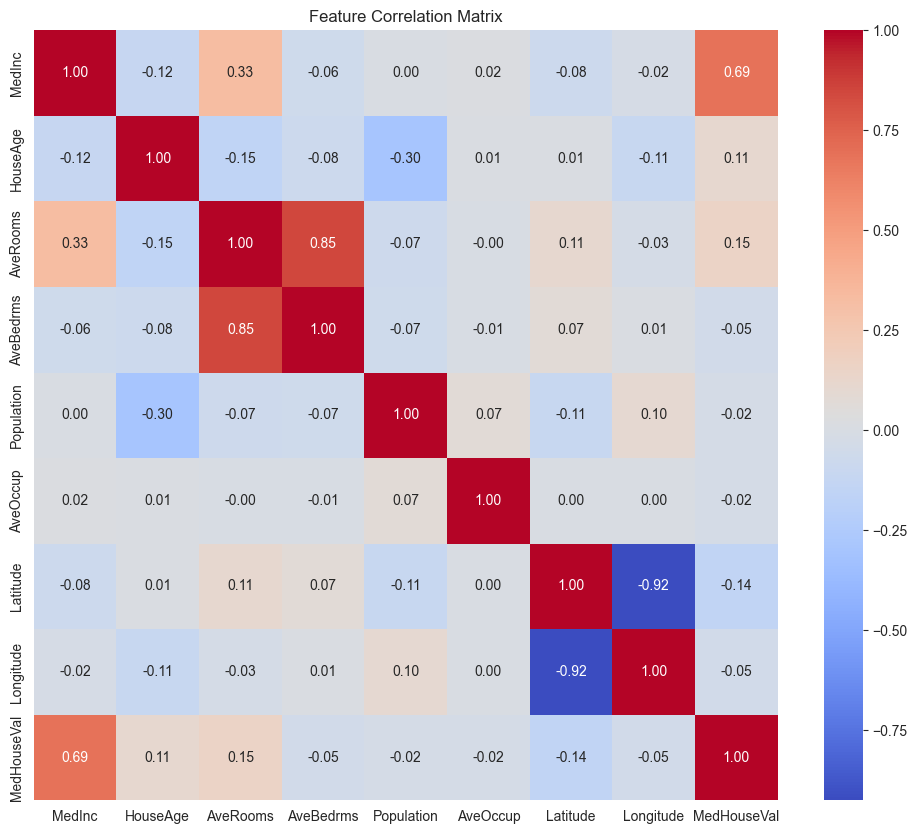

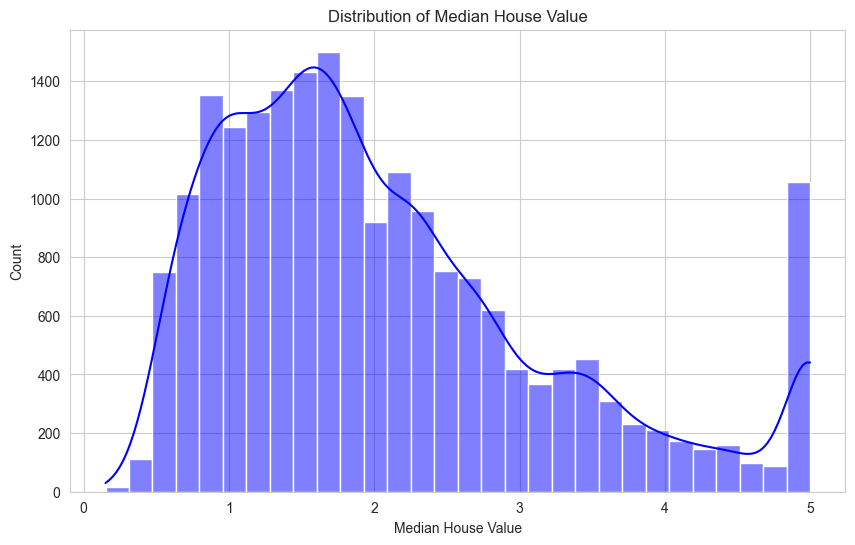

In [7]:
# Correlation heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

# Distribution of the target variable
plt.figure()
sns.histplot(df["MedHouseVal"], kde=True, color="blue", bins=30)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

## 7. Split Data into Training and Testing Sets

Split the dataset into 80% training and 20% testing data. The target variable is `MedHouseVal`.

In [8]:
feature_columns = [col for col in df.columns if col != "MedHouseVal"]
X = df[feature_columns]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 8)
Testing features shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


## 8. Train Linear Regression Model

Create a Linear Regression model and fit it on the training data. Inspect the learned coefficients and intercept.

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model intercept:", model.intercept_)
coefficients = pd.Series(model.coef_, index=feature_columns).sort_values(ascending=False)
print("\nModel coefficients:")
print(coefficients)

Model intercept: -37.0232777060642

Model coefficients:
AveBedrms     0.783145
MedInc        0.448675
HouseAge      0.009724
Population   -0.000002
AveOccup     -0.003526
AveRooms     -0.123323
Latitude     -0.419792
Longitude    -0.433708
dtype: float64


## 9. Make Predictions on Test Data

Use the trained model to predict house prices for the test set and compare predicted values with actual values.

In [10]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).reset_index(drop=True)

prediction_df.head()

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657


## 10. Evaluate Model Performance

Calculate MAE, RMSE, and R² score to measure model accuracy.

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


## 11. Visualize Actual vs Predicted Prices

Plot the relationship between actual and predicted median house values. The closer the points are to the reference line, the better the model fit.

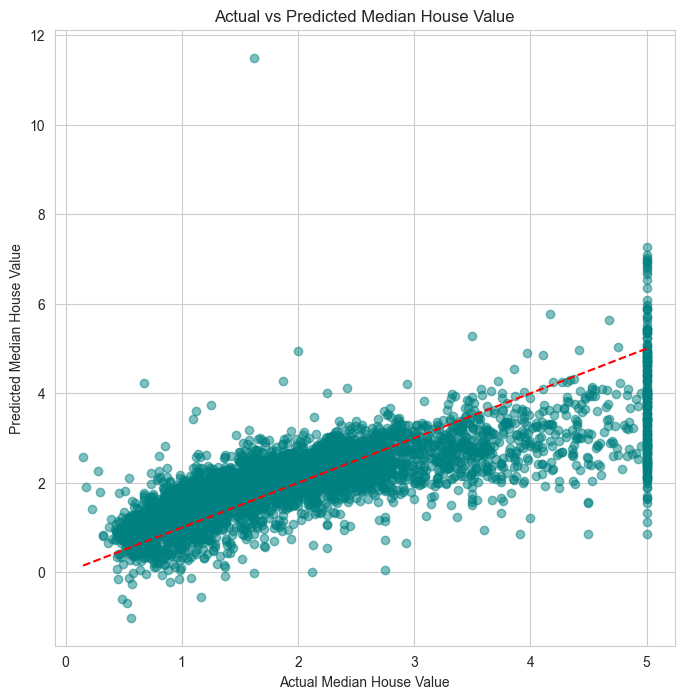

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Median House Value")
plt.show()

## 12. Save Trained Model

Save the trained Linear Regression model to a `.pkl` file so it can be reused later without retraining.

In [13]:
output_model = "linear_regression_california_model.pkl"
with open(output_model, "wb") as f:
    pickle.dump(model, f)

print(f"Saved trained model to: {output_model}")

Saved trained model to: linear_regression_california_model.pkl


## 13. Small Prediction Section

This section loads the saved model and demonstrates how to make a prediction using either manual input values or a sample example.

In [14]:
# Load the saved model and demonstrate predictions.
with open(output_model, "rb") as f:
    loaded_model = pickle.load(f)

print("Feature order:")
for idx, feature in enumerate(feature_columns, 1):
    print(f"{idx}. {feature}")

# Example values for a single prediction. Replace these values with your own.
sample_input_values = df[feature_columns].median().to_dict()
print("\nSample input values (median values):")
for feature, value in sample_input_values.items():
    print(f"{feature}: {value:.4f}")

# Use the sample values by default. Set use_manual_input = True to enter values manually.
use_manual_input = False
input_values = sample_input_values

if use_manual_input:
    print("\nEnter values for the following features:")
    input_values = {}
    for feature in feature_columns:
        raw_value = input(f"{feature}: ")
        input_values[feature] = float(raw_value)

input_data = pd.DataFrame([input_values])
predicted_value = loaded_model.predict(input_data)[0]

print("\nPredicted Median House Value:", round(predicted_value, 4))

Feature order:
1. MedInc
2. HouseAge
3. AveRooms
4. AveBedrms
5. Population
6. AveOccup
7. Latitude
8. Longitude

Sample input values (median values):
MedInc: 3.5348
HouseAge: 29.0000
AveRooms: 5.2291
AveBedrms: 1.0488
Population: 1166.0000
AveOccup: 2.8181
Latitude: 34.2600
Longitude: -118.4900

Predicted Median House Value: 2.0168


## 14. How to Run This Notebook

1. Open `task1_ml_linear_regression.ipynb` in VS Code or Jupyter Notebook.
2. Run each cell in order from top to bottom.
3. If using Jupyter, use `Run -> Run All Cells`.
4. After the model trains, run the prediction section cell.
5. To test a custom prediction, set `use_manual_input = True` in the prediction cell, then rerun that cell and enter values.

This notebook is now complete and ready to use.

## Conclusion

This notebook covers the full machine learning workflow for a Linear Regression house price prediction project. It includes data loading, exploration, model training, evaluation, visualization, and saving the trained model.

Next steps:
- Add feature engineering
- Tune model performance
- Try more advanced regression algorithms
- Build a small UI for predictions
